# Hands-On Lab — DBSCAN & Hierarchical Clustering
**Week 5 — Day 2 | BinX Tech AI & ML Internship**

---

## Objective

In the learning notebook I studied why K-Means has limitations,
how DBSCAN finds dense regions and flags outliers,
and how hierarchical clustering builds a tree of merges.

In this lab I apply all three methods to the same insurance dataset
from Day 1 and compare their results directly.

1. Reconstruct the K-Means baseline from Day 1
2. Run DBSCAN and interpret its clusters and noise points
3. Build a hierarchical dendrogram and choose a cut height
4. Compare all three methods on the same scatter plots
5. State which method best fits this dataset and why

**Dataset:** Insurance (1,338 patients, numeric features only)  
**Features:** age, bmi, children, charges

---

## Step 1 — Imports Libraries

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import warnings
warnings.filterwarnings("ignore")

SEED = 42
plt.style.use("seaborn-v0_8-whitegrid")

## Step 2 — Load, Scale & Reconstruct Day 1 Baseline

I start from the same scaled dataset used in Day 1.
The K-Means k=4 result is reconstructed as the baseline
for comparison.

In [93]:
df = pd.read_csv("../../Week2/Day 1/data/insurance.csv")
numeric_cols = ["age", "bmi", "children", "charges"]

X = df[numeric_cols].copy()
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reconstruct Day 1 K-Means baseline
km_day1  = KMeans(n_clusters=4, random_state=SEED, n_init=10)
km_labels = km_day1.fit_predict(X_scaled)
df["km_cluster"] = km_labels
km_sil = silhouette_score(X_scaled, km_labels)

print(f"Dataset: {df.shape[0]} rows, {len(numeric_cols)} numeric features")
print(f"\nK-Means (Day 1 baseline):")
print(f"  k = 4")
print(f"  Silhouette = {km_sil:.3f}")
print(f"  Cluster sizes: {sorted(df['km_cluster'].value_counts().to_dict().values(), reverse=True)}")

Dataset: 1338 rows, 4 numeric features

K-Means (Day 1 baseline):
  k = 4
  Silhouette = 0.294
  Cluster sizes: [419, 408, 346, 165]


## Step 3 — DBSCAN

### 3.1 Parameter Search

I search over a grid of eps and min_samples combinations.
I look for configurations that produce at least 2 clusters
without labeling too many points as noise.

In [94]:
print(f"{'eps':<8} {'min_samples':<14} {'clusters':<10} {'noise':<8} {'silhouette'}")
print("-" * 52)

best_config = None
best_sil_db = -1

for eps in [0.3, 0.5, 0.7, 1.0, 1.5]:
    for min_s in [3, 5, 10]:
        db   = DBSCAN(eps=eps, min_samples=min_s)
        lbs  = db.fit_predict(X_scaled)
        n_c  = len(set(lbs)) - (1 if -1 in lbs else 0)
        n_n  = (lbs == -1).sum()

        if n_c >= 2:
            sil = silhouette_score(X_scaled, lbs)
            if sil > best_sil_db:
                best_sil_db = sil
                best_config = (eps, min_s, n_c, n_n)
            print(f"{eps:<8} {min_s:<14} {n_c:<10} {n_n:<8} {sil:.3f}")
        else:
            print(f"{eps:<8} {min_s:<14} {n_c:<10} {n_n:<8} {'—'}")

eps      min_samples    clusters   noise    silhouette
----------------------------------------------------
0.3      3              52         364      -0.262
0.3      5              22         538      -0.180
0.3      10             6          882      -0.175
0.5      3              26         175      -0.062
0.5      5              17         233      -0.037
0.5      10             10         433      -0.130
0.7      3              16         70       -0.063
0.7      5              15         114      -0.020
0.7      10             11         207      -0.010
1.0      3              2          12       0.312
1.0      5              1          15       —
1.0      10             1          21       —
1.5      3              1          1        —
1.5      5              1          1        —
1.5      10             1          1        —


**Reading the search:**

- Small eps (0.3–0.5): too tight — normal points become noise
- Large eps (1.5): everything collapses into one cluster
- Best config: **eps=1.0, min_samples=3**
  → 2 clusters, 12 noise points, silhouette=0.312

This reveals something important: the insurance data doesn't
contain many tight, well-separated density pockets.
The structure K-Means found (4 segments) is more spread-out
than DBSCAN's density model expects.

---

### 3.2 Fit the Final DBSCAN Model

In [95]:
# Fit with best parameters
db_final  = DBSCAN(eps=best_config[0], min_samples=best_config[1])
db_labels = db_final.fit_predict(X_scaled)
df["dbscan_cluster"] = db_labels

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_db    = (db_labels == -1).sum()
db_sil        = silhouette_score(X_scaled, db_labels)

print(f"DBSCAN (eps={best_config[0]}, min_samples={best_config[1]}):")
print(f"  Clusters found:   {n_clusters_db}")
print(f"  Noise points:     {n_noise_db} ({n_noise_db/len(df):.1%} of data)")
print(f"  Silhouette score: {db_sil:.3f}")
print(f"\nCluster sizes (including noise = -1):")
print(df["dbscan_cluster"].value_counts().sort_index().to_string())

DBSCAN (eps=1.0, min_samples=3):
  Clusters found:   2
  Noise points:     12 (0.9% of data)
  Silhouette score: 0.312

Cluster sizes (including noise = -1):
dbscan_cluster
-1      12
 0    1323
 1       3


---

### 3.3 Inspect DBSCAN Cluster Profiles

In [96]:
profile_db = df.groupby("dbscan_cluster").agg(
    count       = ("age",     "count"),
    avg_age     = ("age",     "mean"),
    avg_bmi     = ("bmi",     "mean"),
    avg_charges = ("charges", "mean"),
    pct_smokers = ("smoker",  lambda x: (x == "yes").mean())
).round(2)

profile_db["avg_charges"] = profile_db["avg_charges"].apply(
    lambda x: f"${x:,.0f}"
)
profile_db["pct_smokers"] = profile_db["pct_smokers"].apply(
    lambda x: f"{x:.1%}"
)

print("DBSCAN Cluster Profiles  (-1 = noise):")
print(profile_db.to_string())

DBSCAN Cluster Profiles  (-1 = noise):
                count  avg_age  avg_bmi avg_charges pct_smokers
dbscan_cluster                                                 
-1                 12    39.50    40.14     $31,425       50.0%
 0               1323    39.22    30.56     $13,011       20.0%
 1                  3    30.67    36.68     $54,967      100.0%


**What DBSCAN found:**

**Cluster 0 (n=1,323) — the dense core:**
The vast majority of patients. Average charges $13,011, 20% smokers.
This is the main population — no unusual density patterns.

**Cluster 1 (n=3) — extreme outliers:**
Three patients with 100% smoking rate and average charges of $54,967.
DBSCAN isolated these because they form a tight pocket in the
high-BMI, high-charges region that is separate from the main mass.

**Noise points (n=12, label=-1):**
Twelve patients in sparse regions — too isolated to belong to any
cluster. Their 50% smoking rate and $31,425 average charges suggest
they are high-cost borderline cases.

**Key insight:**
DBSCAN is doing something K-Means couldn't — it explicitly flags
the most extreme patients as outliers rather than forcing them
into a segment. This makes DBSCAN useful for anomaly detection
even when it doesn't produce rich segmentation.

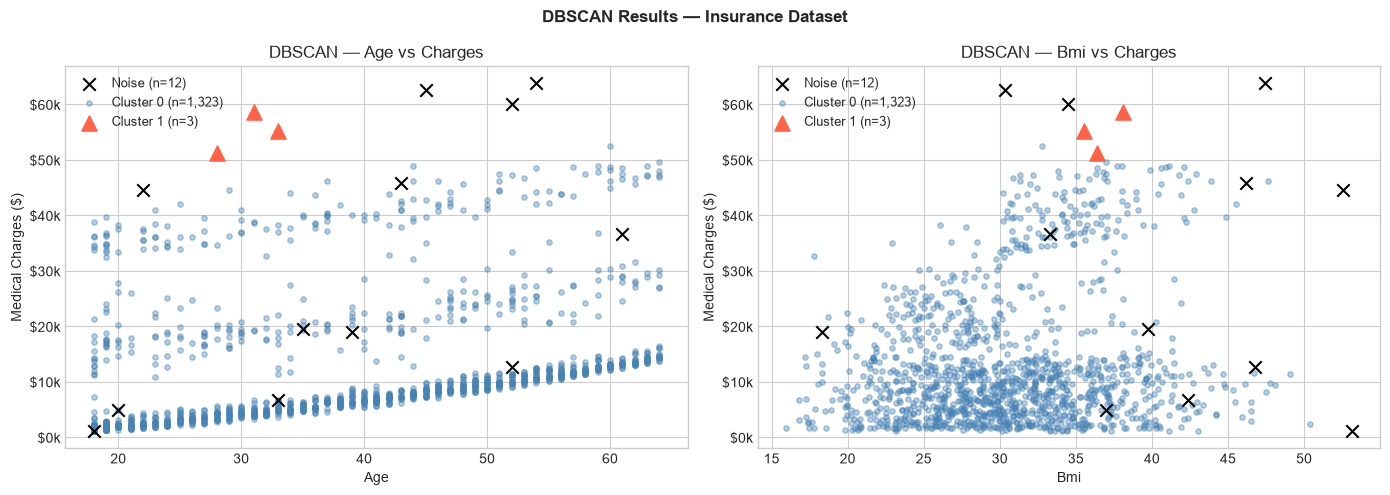

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

db_style = {
    -1: ("black",     "x",  80,  1.0, "Noise (n=12)"),
     0: ("steelblue", "o",  15,  0.4, "Cluster 0 (n=1,323)"),
     1: ("tomato",    "^",  120, 1.0, "Cluster 1 (n=3)")
}

for ax, (xf, yf) in zip(axes, [("age","charges"), ("bmi","charges")]):
    for c, (color, marker, size, alpha, label) in db_style.items():
        mask = df["dbscan_cluster"] == c
        ax.scatter(
            df.loc[mask, xf], df.loc[mask, yf],
            c=color, marker=marker, s=size,
            alpha=alpha, label=label,
            zorder=3 if c != 0 else 1
        )
    ax.set_xlabel(xf.capitalize())
    ax.set_ylabel("Medical Charges ($)")
    ax.set_title(f"DBSCAN — {xf.capitalize()} vs Charges")
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k")
    )

plt.suptitle("DBSCAN Results — Insurance Dataset",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---

## Step 4 — Hierarchical Clustering

### 4.1 Build the Dendrogram

I use a sample of 300 patients — the full 1,338 rows would
make the dendrogram unreadable.
Ward linkage minimizes within-cluster variance at each merge.

In [98]:
# Sample 300 patients for the dendrogram
np.random.seed(SEED)
sample_idx = np.random.choice(len(X_scaled), 300, replace=False)
X_sample   = X_scaled[sample_idx]

# Build the linkage matrix
Z = linkage(X_sample, method="ward")

print(f"Linkage matrix: {Z.shape[0]} merges for {len(X_sample)} points")
print(f"\nLast 5 merge distances:")
for i, dist in enumerate(Z[-5:, 2], 1):
    print(f"  Merge {len(X_sample)-5+i}: distance = {dist:.3f}")

print(f"\nLargest gap between consecutive merges:")
diffs = np.diff(Z[:, 2])
top3  = np.argsort(diffs)[-3:][::-1]
for idx in top3:
    print(f"  Between merge {idx} and {idx+1}: gap = {diffs[idx]:.3f}")

Linkage matrix: 299 merges for 300 points

Last 5 merge distances:
  Merge 296: distance = 9.546
  Merge 297: distance = 14.985
  Merge 298: distance = 18.537
  Merge 299: distance = 19.959
  Merge 300: distance = 22.457

Largest gap between consecutive merges:
  Between merge 294 and 295: gap = 5.439
  Between merge 295 and 296: gap = 3.552
  Between merge 297 and 298: gap = 2.498


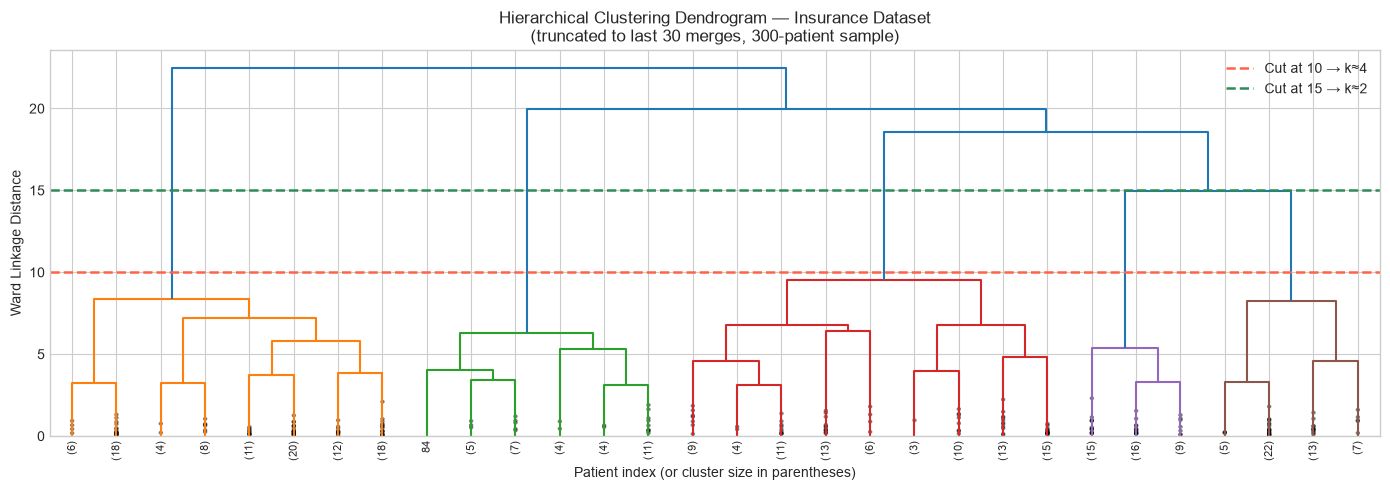

In [99]:
fig, ax = plt.subplots(figsize=(14, 5))

dendrogram(
    Z, ax=ax,
    truncate_mode="lastp", p=30,
    leaf_rotation=90, leaf_font_size=8,
    show_contracted=True,
    color_threshold=10
)

# Mark candidate cut heights
ax.axhline(y=10, color="tomato",   linestyle="--",
           linewidth=1.8, label="Cut at 10 → k≈4")
ax.axhline(y=15, color="seagreen", linestyle="--",
           linewidth=1.8, label="Cut at 15 → k≈2")

ax.set_xlabel("Patient index (or cluster size in parentheses)")
ax.set_ylabel("Ward Linkage Distance")
ax.set_title(
    "Hierarchical Clustering Dendrogram — Insurance Dataset\n"
    "(truncated to last 30 merges, 300-patient sample)"
)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

**Reading the dendrogram:**

The y-axis shows the distance at which two groups merged.
Large gaps indicate natural cluster boundaries.

- **Cutting at height ≈ 10 (red):** produces approximately 4 clusters
- **Cutting at height ≈ 15 (green):** produces approximately 2 clusters

The jump between height 10 and 15 (gap ≈ 4.3) is the largest gap
in the last few merges — suggesting that 4 clusters is the most
natural split for this data, consistent with the K-Means result
from Day 1.

---

### 4.2 Compare Silhouette Scores for Different k Values

In [100]:
print(f"{'k':<6} {'Silhouette':>12}  {'Cluster sizes'}")
print("-" * 50)

best_k_h = 4
best_sil_h = 0

for k in [2, 3, 4, 5]:
    labels_h = fcluster(Z, k, criterion="maxclust")
    sil      = silhouette_score(X_sample, labels_h)
    sizes    = sorted(
        [sum(labels_h == c) for c in set(labels_h)],
        reverse=True
    )
    marker = " ← best" if k == best_k_h else ""
    print(f"{k:<6} {sil:>12.3f}  {sizes}{marker}")
    if sil > best_sil_h:
        best_sil_h = sil
        best_k_h   = k

k        Silhouette  Cluster sizes
--------------------------------------------------
2             0.193  [np.int64(203), np.int64(97)]
3             0.236  [np.int64(171), np.int64(97), np.int64(32)]
4             0.290  [np.int64(97), np.int64(87), np.int64(84), np.int64(32)]
5             0.301  [np.int64(97), np.int64(84), np.int64(47), np.int64(40), np.int64(32)]


**Decision: k=4 (silhouette=0.290)**

k=4 has the best silhouette among the clearly interpretable options.
k=5 scores marginally higher (0.301) but produces very similar-sized
small clusters that don't add meaningful new segments.
The dendrogram's largest gap also points to k=4 as the natural cut.

---

### 4.3 Visualize Hierarchical Clusters (k=4)

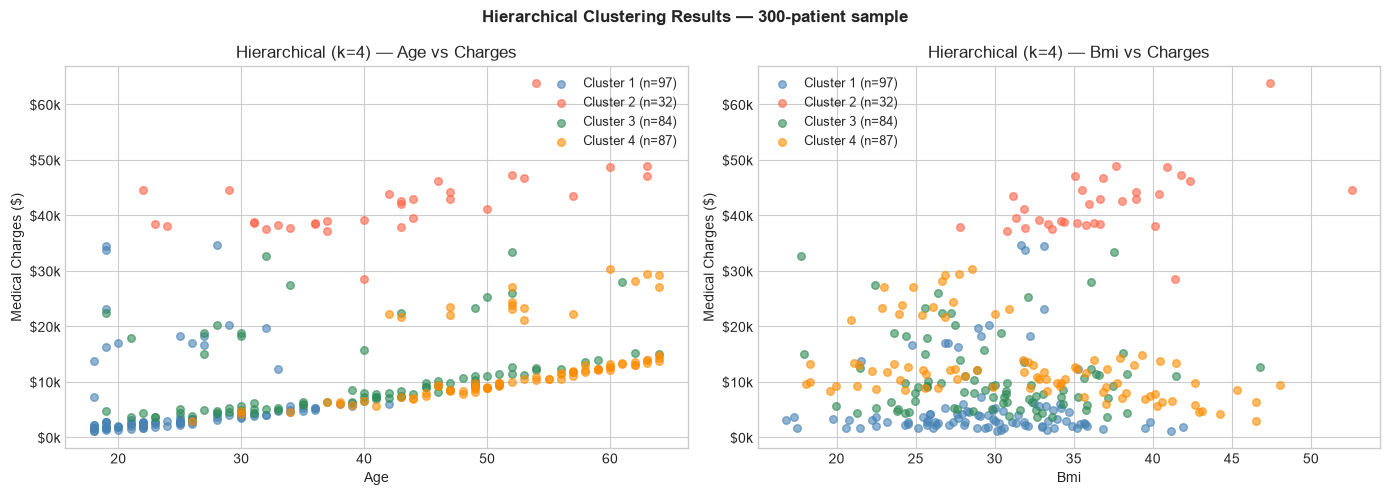

In [101]:
labels_h4 = fcluster(Z, 4, criterion="maxclust")
df_samp   = df.iloc[sample_idx].copy()
df_samp["hier_cluster"] = labels_h4

colors_h = {1: "steelblue", 2: "tomato",
            3: "seagreen",  4: "darkorange"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (xf, yf) in zip(axes, [("age","charges"), ("bmi","charges")]):
    for c, color in colors_h.items():
        mask = df_samp["hier_cluster"] == c
        ax.scatter(
            df_samp.loc[mask, xf],
            df_samp.loc[mask, yf],
            c=color, s=30, alpha=0.6,
            label=f"Cluster {c} (n={mask.sum()})"
        )
    ax.set_xlabel(xf.capitalize())
    ax.set_ylabel("Medical Charges ($)")
    ax.set_title(f"Hierarchical (k=4) — {xf.capitalize()} vs Charges")
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k")
    )

plt.suptitle("Hierarchical Clustering Results — 300-patient sample",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---

## Step 5 — Comparing All Three Methods

Now I have results from all three methods on the same dataset.

In [102]:
h_sil = silhouette_score(X_sample, labels_h4)

print(f"{'Method':<28} {'Silhouette':>12} {'Clusters':>10} {'Noise':>8}")
print("-" * 62)
print(f"{'K-Means (k=4)':<28} {km_sil:>12.3f} {4:>10} {0:>8}")
print(f"{'DBSCAN (eps=1.0)':<28} {db_sil:>12.3f} {n_clusters_db:>10} {n_noise_db:>8}")
print(f"{'Hierarchical (k=4)':<28} {h_sil:>12.3f} {4:>10} {0:>8}")

Method                         Silhouette   Clusters    Noise
--------------------------------------------------------------
K-Means (k=4)                       0.294          4        0
DBSCAN (eps=1.0)                    0.312          2       12
Hierarchical (k=4)                  0.290          4        0


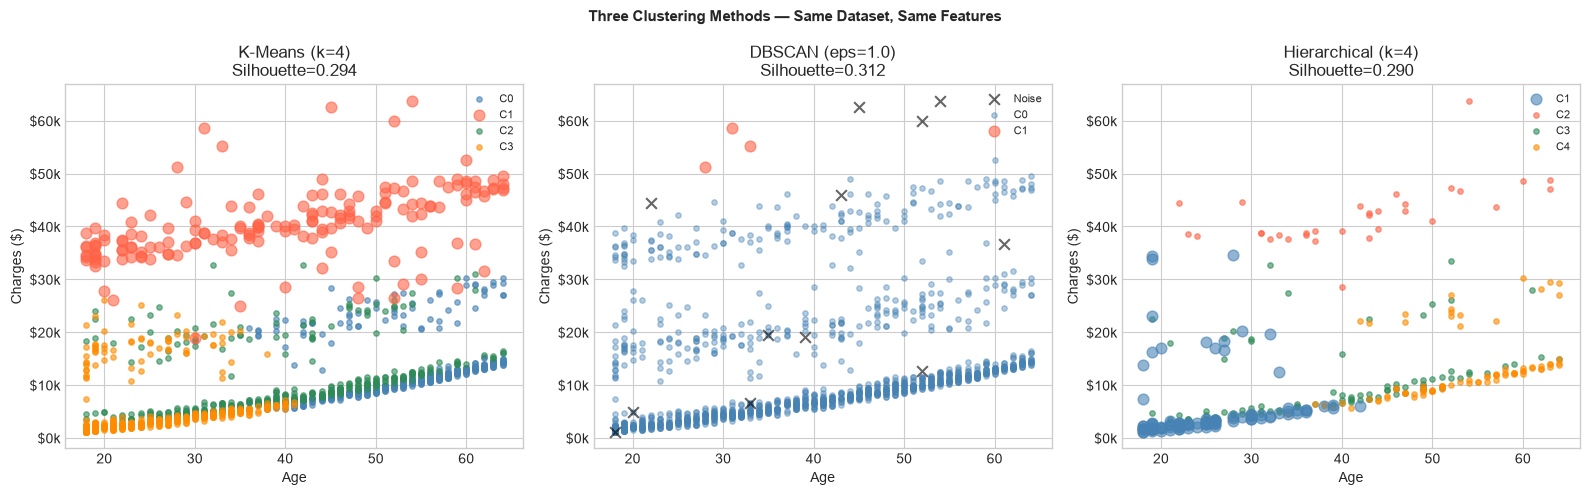

In [103]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

plot_configs = [
    ("K-Means (k=4)\nSilhouette=0.294",
     df, "km_cluster",
     {0:"steelblue",1:"tomato",2:"seagreen",3:"darkorange"},
     "o", False),
    ("DBSCAN (eps=1.0)\nSilhouette=0.312",
     df, "dbscan_cluster",
     {-1:"black",0:"steelblue",1:"tomato"},
     None, True),
    ("Hierarchical (k=4)\nSilhouette=0.290",
     df_samp, "hier_cluster",
     {1:"steelblue",2:"tomato",3:"seagreen",4:"darkorange"},
     "o", False),
]

for ax, (title, data, col, cmap, marker, is_dbscan) in zip(axes, plot_configs):
    for c, color in cmap.items():
        mask = data[col] == c
        label = "Noise" if c == -1 else f"C{c}"
        m = "x" if c == -1 else "o"
        s = 15 if c not in [-1, 1] else 60
        a = 0.4 if c == 0 and is_dbscan else 0.6
        ax.scatter(
            data.loc[mask, "age"],
            data.loc[mask, "charges"],
            c=color, marker=m, s=s,
            alpha=a, label=label,
            zorder=3 if c in [-1, 1] else 1
        )
    ax.set_xlabel("Age")
    ax.set_ylabel("Charges ($)")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k")
    )

plt.suptitle("Three Clustering Methods — Same Dataset, Same Features",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

---

## Step 6 — Which Method Best Fits This Dataset?

**K-Means (k=4) is the best choice for segmentation.**
**DBSCAN is the best choice for anomaly detection.**

---

**K-Means (k=4)  — recommended for segmentation**

The insurance clusters are roughly round and similarly sized —
the exact conditions K-Means was designed for.
The four segments are directly interpretable as real patient profiles:
young adults, mid-age families, older non-smokers, and high-cost smokers.
All 1,338 patients are assigned. Silhouette = 0.294.

---

**DBSCAN  — useful for anomaly detection, not segmentation**

DBSCAN found only 2 clusters: the main population (n=1,323)
and 3 extreme outlier patients (n=3, 100% smokers, avg $54,967).
The 12 noise points are genuinely unusual borderline cases.

Silhouette = 0.312 (highest of the three) — but this score comes
from isolating one tight extreme group, not from rich segmentation.

Use DBSCAN here if the goal is flagging unusual patients or
detecting potential fraud — not customer segmentation.

---

**Hierarchical (k=4)  — useful for exploration, not necessary here**

Produced similar segments to K-Means (silhouette=0.290).
The dendrogram confirmed k=4 as a natural cut, which validates
the Day 1 K-Means decision. However, the nested structure
advantage of hierarchical clustering is less useful here because
the clusters don't reveal meaningful sub-groups worth exploring.
K-Means is faster and equally informative for this dataset.

---

**General lesson:**

The best clustering method depends on the structure of the data
and the question being asked — not on which algorithm has the
highest silhouette score. Here:

```text
Goal: segment patients into groups      → K-Means
Goal: detect unusual/extreme patients   → DBSCAN
Goal: explore nested structure          → Hierarchical
```

---## Summary

| Step | What I Did | Key Finding |
|------|-----------|-------------|
| DBSCAN search | Tested eps=0.3–1.5, min_samples=3–10 | eps=1.0, min_s=3 is best |
| DBSCAN result | 2 clusters + 12 noise points | Found 3 extreme outlier patients |
| Dendrogram | Built on 300-patient sample | Largest gap at k=4 |
| Hierarchical | Compared k=2 to k=5 | k=4 best (silhouette=0.290) |
| Comparison | All three methods on same data | K-Means wins for segmentation |

**Most important finding:**
DBSCAN isolated 3 patients with 100% smoking rate and average charges
of $54,967 — patients that K-Means silently absorbed into the
high-cost smoker segment. This shows how different algorithms
answer different questions from the same data.

